In [266]:
import numpy as np
import pandas as pd

In [297]:
class CustomLogisticRegression:
    def __init__(self, max_iter = 100):
        self.max_iter = max_iter
        self.w = None
        self.coef_ = None
        self.intercept_ = None
        self.m , self.b = None, None

    def sigmoid(self,val):
        val = np.clip(val, -500, 500)
        return 1/(1+np.exp(-val))

    def fit(self,x,y, lr = 0.5):
        
        x = np.insert(x,0,1, axis=1)
        self.w = np.zeros(x.shape[1])

        for _ in range(self.max_iter):
            y_pred = self.sigmoid(x.dot(self.w))
            dw = -(np.dot((y-y_pred), x)/x.shape[0])
            self.w = self.w - lr * dw

        self.coef_ = self.w[1:]
        self.intercept_ = self.w[0]

        self.m = -(self.coef_[0]/self.coef_[1])
        self.b = -(self.intercept_/self.coef_[1])

    def predict(self, x_test):
        x_test = np.insert(x_test,0,1, axis=1)
        probablity = self.sigmoid(x_test.dot(self.w))
        return np.array(np.where(probablity>0.5,1,0)).flatten()





In [298]:
from sklearn.datasets import load_breast_cancer
df = load_breast_cancer(as_frame=True)
df = pd.DataFrame(pd.concat([df.data, df.target.rename('target')], axis = 1))


from sklearn.model_selection import train_test_split
x = df.drop(columns = 'target')
y = df['target']

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=.2, random_state=32)


In [299]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [300]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(penalty = None, solver='sag')
model.fit(x, y)
m1 = -(model.coef_[0][0]/model.coef_[0][1])
b1 = -(model.intercept_/model.coef_[0][1])
m1,b1

c:\Users\vansh\anaconda3\envs\DataScience\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\vansh\anaconda3\envs\DataScience\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


(np.float64(-0.5738839408463186), array([-0.07756496]))

In [301]:
model.predict(x_test)

c:\Users\vansh\anaconda3\envs\DataScience\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0,
       1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 1])

In [302]:
model1 = CustomLogisticRegression()
model1.fit(x, y)
m2 = model1.m
b2 = model1.b
m2, b2


(np.float64(-0.5392996102703554), np.float64(-0.0667616598260998))

In [303]:
model1.predict(x_test)

array([0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0,
       1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 1])

In [295]:
x_input = np.linspace(-3,3,100)
y_input = m1*x_input + b1

x_input1 = np.linspace(-3,3,100)
y_input1 = m2*x_input1 + b2

In [296]:
x = np.array(x)

(-3.0, 2.0)

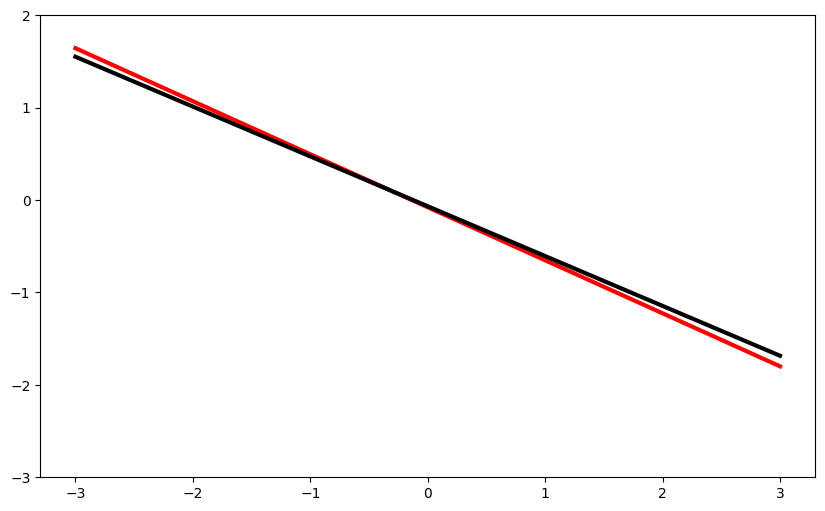

In [304]:
x_input = np.linspace(-3,3,100)
y_input = m1*x_input + b1
x_input1 = np.linspace(-3,3,100)
y_input1 = m2*x_input1 + b2
x = np.array(x)

import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.ylim(-3,2)
